#  미로 만들기 
## 문제
n×n 바둑판 모양으로 총 n^2개의 방이 있다. 일부분은 검은 방이고 나머지는 모두 흰 방이다. 검은 방은 사면이 벽으로 싸여 있어 들어갈 수 없다. 서로 붙어 있는 두 개의 흰 방 사이에는 문이 있어서 지나다닐 수 있다. 윗줄 맨 왼쪽 방은 시작방으로서 항상 흰 방이고, 아랫줄 맨 오른쪽 방은 끝방으로서 역시 흰 방이다.

시작방에서 출발하여 길을 찾아서 끝방으로 가는 것이 목적인데, 아래 그림의 경우에는 시작방에서 끝 방으로 갈 수가 없다. 부득이 검은 방 몇 개를 흰 방으로 바꾸어야 하는데 되도록 적은 수의 방의 색을 바꾸고 싶다.

아래 그림은 n=8인 경우의 한 예이다.

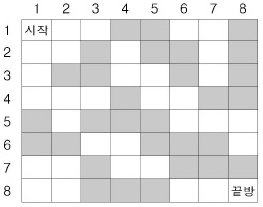

위 그림에서는 두 개의 검은 방(예를 들어 (4,4)의 방과 (7,8)의 방)을 흰 방으로 바꾸면, 시작방에서 끝방으로 갈 수 있지만, 어느 검은 방 하나만을 흰 방으로 바꾸어서는 불가능하다. 검은 방에서 흰 방으로 바꾸어야 할 최소의 수를 구하는 프로그램을 작성하시오.

단, 검은 방을 하나도 흰방으로 바꾸지 않아도 되는 경우는 0이 답이다.

## 입력
첫 줄에는 한 줄에 들어가는 방의 수 n(1 ≤ n ≤ 50)이 주어지고, 다음 n개의 줄의 각 줄마다 0과 1이 이루어진 길이가 n인 수열이 주어진다. 0은 검은 방, 1은 흰 방을 나타낸다.

## 출력
첫 줄에 흰 방으로 바꾸어야 할 최소의 검은 방의 수를 출력한다.

## 예제 입력 1
```
8
11100110
11010010
10011010
11101100
01000111
00110001
11011000
11000111
```

## 예제 출력 1
2

In [ ]:
# 이건 해결책이 안 떠오르므로 다른 사람 답안 먼저 확인 후 작성해 볼 것 
# 출처: https://growth-coder.tistory.com/233 
# 그런데 백준 제출 시 시간 초과 발생. 시간 초과 해결할 수 있는 방법 있을까? 
# 기본 원리: 방문한 노드를 재방문하기
import sys
### 백준 제출 시 제거
import io
input_data = """8
11100110
11010010
10011010
11101100
01000111
00110001
11011000
11000111
"""
sys.stdin = io.StringIO(input_data)
### 여기까지 제거 
input = sys.stdin.readline

from collections import deque
# 동서남북
dx = [-1, 1, 0, 0]
dy = [0, 0, -1, 1]

n = int(input()) # 지도 크기 받기
# arr = [list(input().rstrip()) for _ in range(n)] # 지도 정보 받기 
arr = [list(map(int, input().rstrip())) for _ in range(n)] # 지도 정보 받기 
cnt = [[1e9] * n for _ in range(n)] # 흰 방으로 바꾼 횟수. 

queue = deque()

# 왼쪽 가장 위쪽 방은 시작점으로 항상 하얀 방
queue.append((0, 0))
cnt[0][0] = 0 

while queue:
    x, y = queue.popleft()
    for i in range(len(dx)):
        nx = x + dx[i]
        ny = y + dy[i]

        # nx, ny가 올바른 영역 내에 있는 지 체크
        if 0 <= nx < n and 0 <= ny < n: 
            # 방문할 방이 흰 방이고 이번 방문 노드값 > 이전 노드 방문값일 때 방문 
            # if arr[nx][ny] == '1' and cnt[nx][ny] > cnt[x][y]:
            if arr[nx][ny] == 1 and cnt[nx][ny] > cnt[x][y]:
                cnt[nx][ny] = cnt[x][y]
                queue.append((nx, ny))
            # 방문할 방이 검은 방이고, 이번 방문 노드값 > 이전 노드 방문값일 때 방문하며 방문 횟수 갱신 
            # elif arr[nx][ny] == '0' and cnt[nx][ny] > cnt[x][y]:
            elif arr[nx][ny] == 0 and cnt[nx][ny] > cnt[x][y]:
                cnt[nx][ny] = cnt[x][y] + 1
                queue.append((nx, ny))

print(cnt[n-1][n-1])



2
